##### top

# FMP modelling for Figure 3 (Cue stimulus)

This notebook runs Bayesian models on Datasets 3 (dataset with randomising cue stimulus) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP and to assess the effect of cue stimulus. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), and `userID` as a variable denoting individual participants. The reference levels are UD level 1.

Unlike in `FMP_fit_linear_regression-Figure3-cue_stimulus.ipynb`, here we first separate the datasets according to the cue stimulus (`target_loc_simple` labels the morphing status of the cue stimulus; unmorphed = `target_0`, morphed = `other`) and subsequently fit models as before.


* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')

path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
    'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
}


# load all dataframes
df_dic = {}

# only selected cols
select_cols = ['stim1', 'stim2', 'target', 'RT', 'userID', 'difficulty', 'levels', 'task', 'correct_flt', 'order']


for f in path_dic.keys():   
    if 'dataset_3' in f:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols+['target_loc', 'target_loc_simple'])
    else:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols)
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)
        
    
    # find low performing participants
    tt = df_dic[f].loc[df_dic[f]['task'].isin(['face matching', 'perc', 'perception'])].groupby(['userID', 'difficulty']).correct_flt.mean()

    drop_ptc = tt[tt<=0.5].reset_index().userID.values
    print(f'\nIn {f} dropping {len(drop_ptc)} participants for low accuracy in FM.')
    print(tt[tt<=0.5])

    # and remove them
    df_dic[f] = df_dic[f].loc[~df_dic[f]['userID'].isin(drop_ptc)]
    # clean up
    drop_ptc, tt = None, None
    
    print(f"\nThere is now N={df_dic[f]['userID'].unique().size} participants in {f}.")



#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']



# rename the memory task labels in the df
for f in df_dic.keys():
    if f=='noise':
        continue
    df_dic[f]['task'] = df_dic[f]['task'].map(rename_tasks_dic).fillna(df_dic[f]['task'])

    
    
# add two datasets for the longitudinal split based on cue stimuli (target) location
# take only other -> morphed
df_dic['dataset_3_other'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='other'].copy()

# take only target 0 -> unmorphed
df_dic['dataset_3_target_0'] = df_dic['dataset_3'].loc[df_dic['dataset_3']['target_loc_simple']=='target_0'].copy()


We will have 4 cores.


In dataset_3 dropping 0 participants for low accuracy in FM.
Series([], Name: correct_flt, dtype: float64)

There is now N=262 participants in dataset_3.


In [2]:
# select only specific datasets and prepare them
datasets2fit = ['dataset_3_other', 'dataset_3_target_0']

df_dic_fit = {}


for f in datasets2fit:
    data=None
    
    # groupby and make means for ptc and condition
    data = df_dic[f].groupby(['userID', 'task', 'difficulty'], observed=False).correct_flt.mean().reset_index()

    # convert all variables to categories
    # categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
    categorical_cols = ['userID', 'task', 'difficulty']
    for col in categorical_cols:
        if col == 'task':
            # specify the order that we want
            data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
            #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']
            
            # also do it for the original datasets
            df_dic[f][col] = pd.Categorical(df_dic[f][col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
        else:
            data[col] = data[col].astype("category")
            df_dic[f][col] = df_dic[f][col].astype("category")

    # check
    print('\n',f)
    df_dic[f].info()
        
    # save
    df_dic_fit[f] = data.copy()

# # drop them for now
# data[data.correct_flt.isna()]


 dataset_3_other
<class 'pandas.core.frame.DataFrame'>
Index: 12875 entries, 0 to 47158
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   stim1              12875 non-null  object  
 1   stim2              12875 non-null  object  
 2   target             12875 non-null  object  
 3   RT                 12517 non-null  float64 
 4   userID             12875 non-null  category
 5   task               12875 non-null  category
 6   order              12875 non-null  int64   
 7   difficulty         12875 non-null  category
 8   levels             12875 non-null  int64   
 9   correct_flt        12517 non-null  float64 
 10  target_loc_simple  12875 non-null  object  
 11  target_loc         12875 non-null  object  
 12  Experiment         12875 non-null  object  
dtypes: category(3), float64(2), int64(2), object(6)
memory usage: 1.1+ MB

 dataset_3_target_0
<class 'pandas.core.frame.DataFrame'>
Index: 34

## Models
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
}

# define what we want to run
formulas2run = [
    "correct_flt ~ task * difficulty + (1|userID)",
    "correct_flt ~ task + difficulty + (1|userID)",
]

In [4]:
# define where we will store the results
model_dic_bernoulli = {}
result_dic_bernoulli = {}

for f in df_dic_fit.keys():
    print(f'\nFitting dataset {f}\n')
    # create datasets
    if f not in model_dic_bernoulli.keys():
        model_dic_bernoulli[f] = {}
    if f not in result_dic_bernoulli.keys():
        result_dic_bernoulli[f] = {}
    
    for formula in formulas2run:
        print(f'\nFitting formula {formula}\n')
    
        model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula] = fit_model(formula, df_dic_fit[f], categorical_cols,
                                                                                      num_cpu=num_cpu, check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:23

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.


In [5]:
model_dic_bernoulli[f][formulas2run[0]]

       Formula: correct_flt ~ task * difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7703, sigma: 0.7842)
            task ~ Normal(mu: [0. 0.], sigma: [0.8886 0.8929])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.89 0.89])
            task:difficulty ~ Normal(mu: [0. 0. 0. 0.], sigma: [1.3313 1.3313 1.3426 1.3426])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7842))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [6]:
model_dic_bernoulli[f][formulas2run[1]]

       Formula: correct_flt ~ task + difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 2343
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7703, sigma: 0.7261)
            task ~ Normal(mu: [0. 0.], sigma: [0.8886 0.8929])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.89 0.89])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7261))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1678)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

### check priors

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task, task:difficulty]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>],
       [<Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task:difficulty\nMatching, 2'}>,
        <Axes: title={'center': 'task:difficulty\nMatching, 3'}>,
        <Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 2'}>],
       [<Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 3'}>,
        <Axes: title={'center': '1|userID_sigma'}>, <Axes: >]],
      dtype=object)

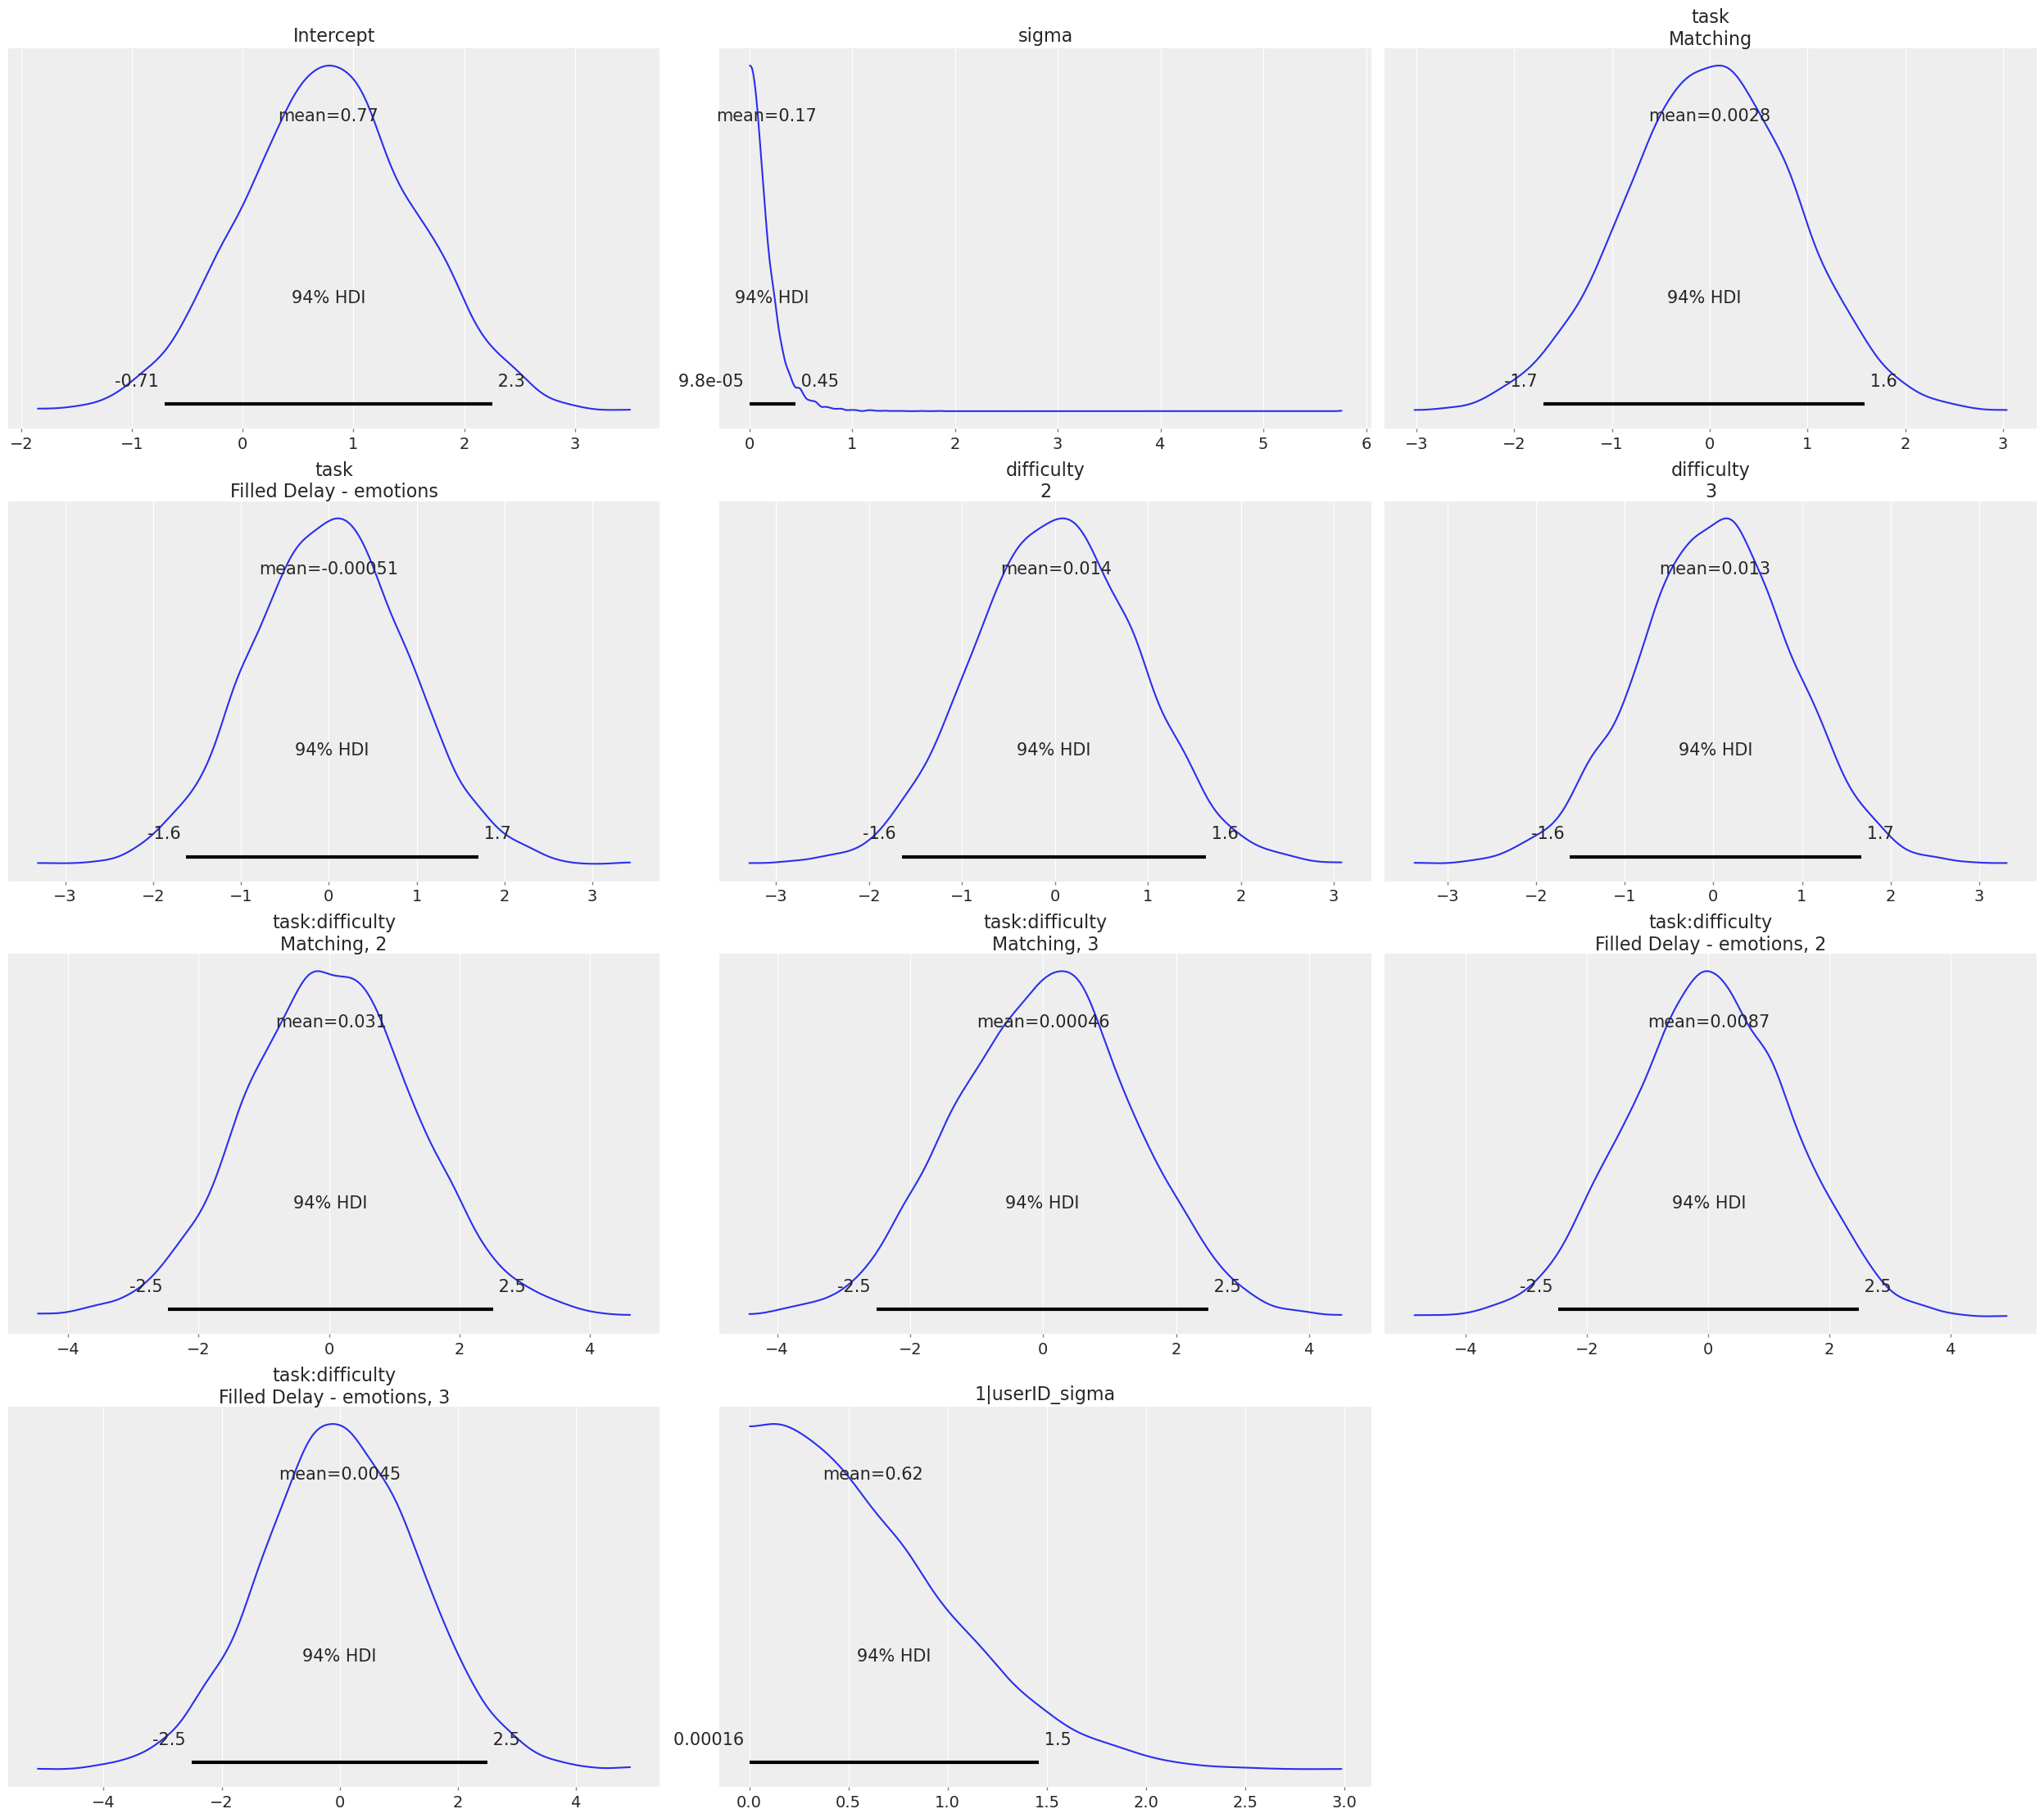

In [7]:
model_dic_bernoulli[f][formulas2run[0]].plot_priors()

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>],
       [<Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': '1|userID_sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

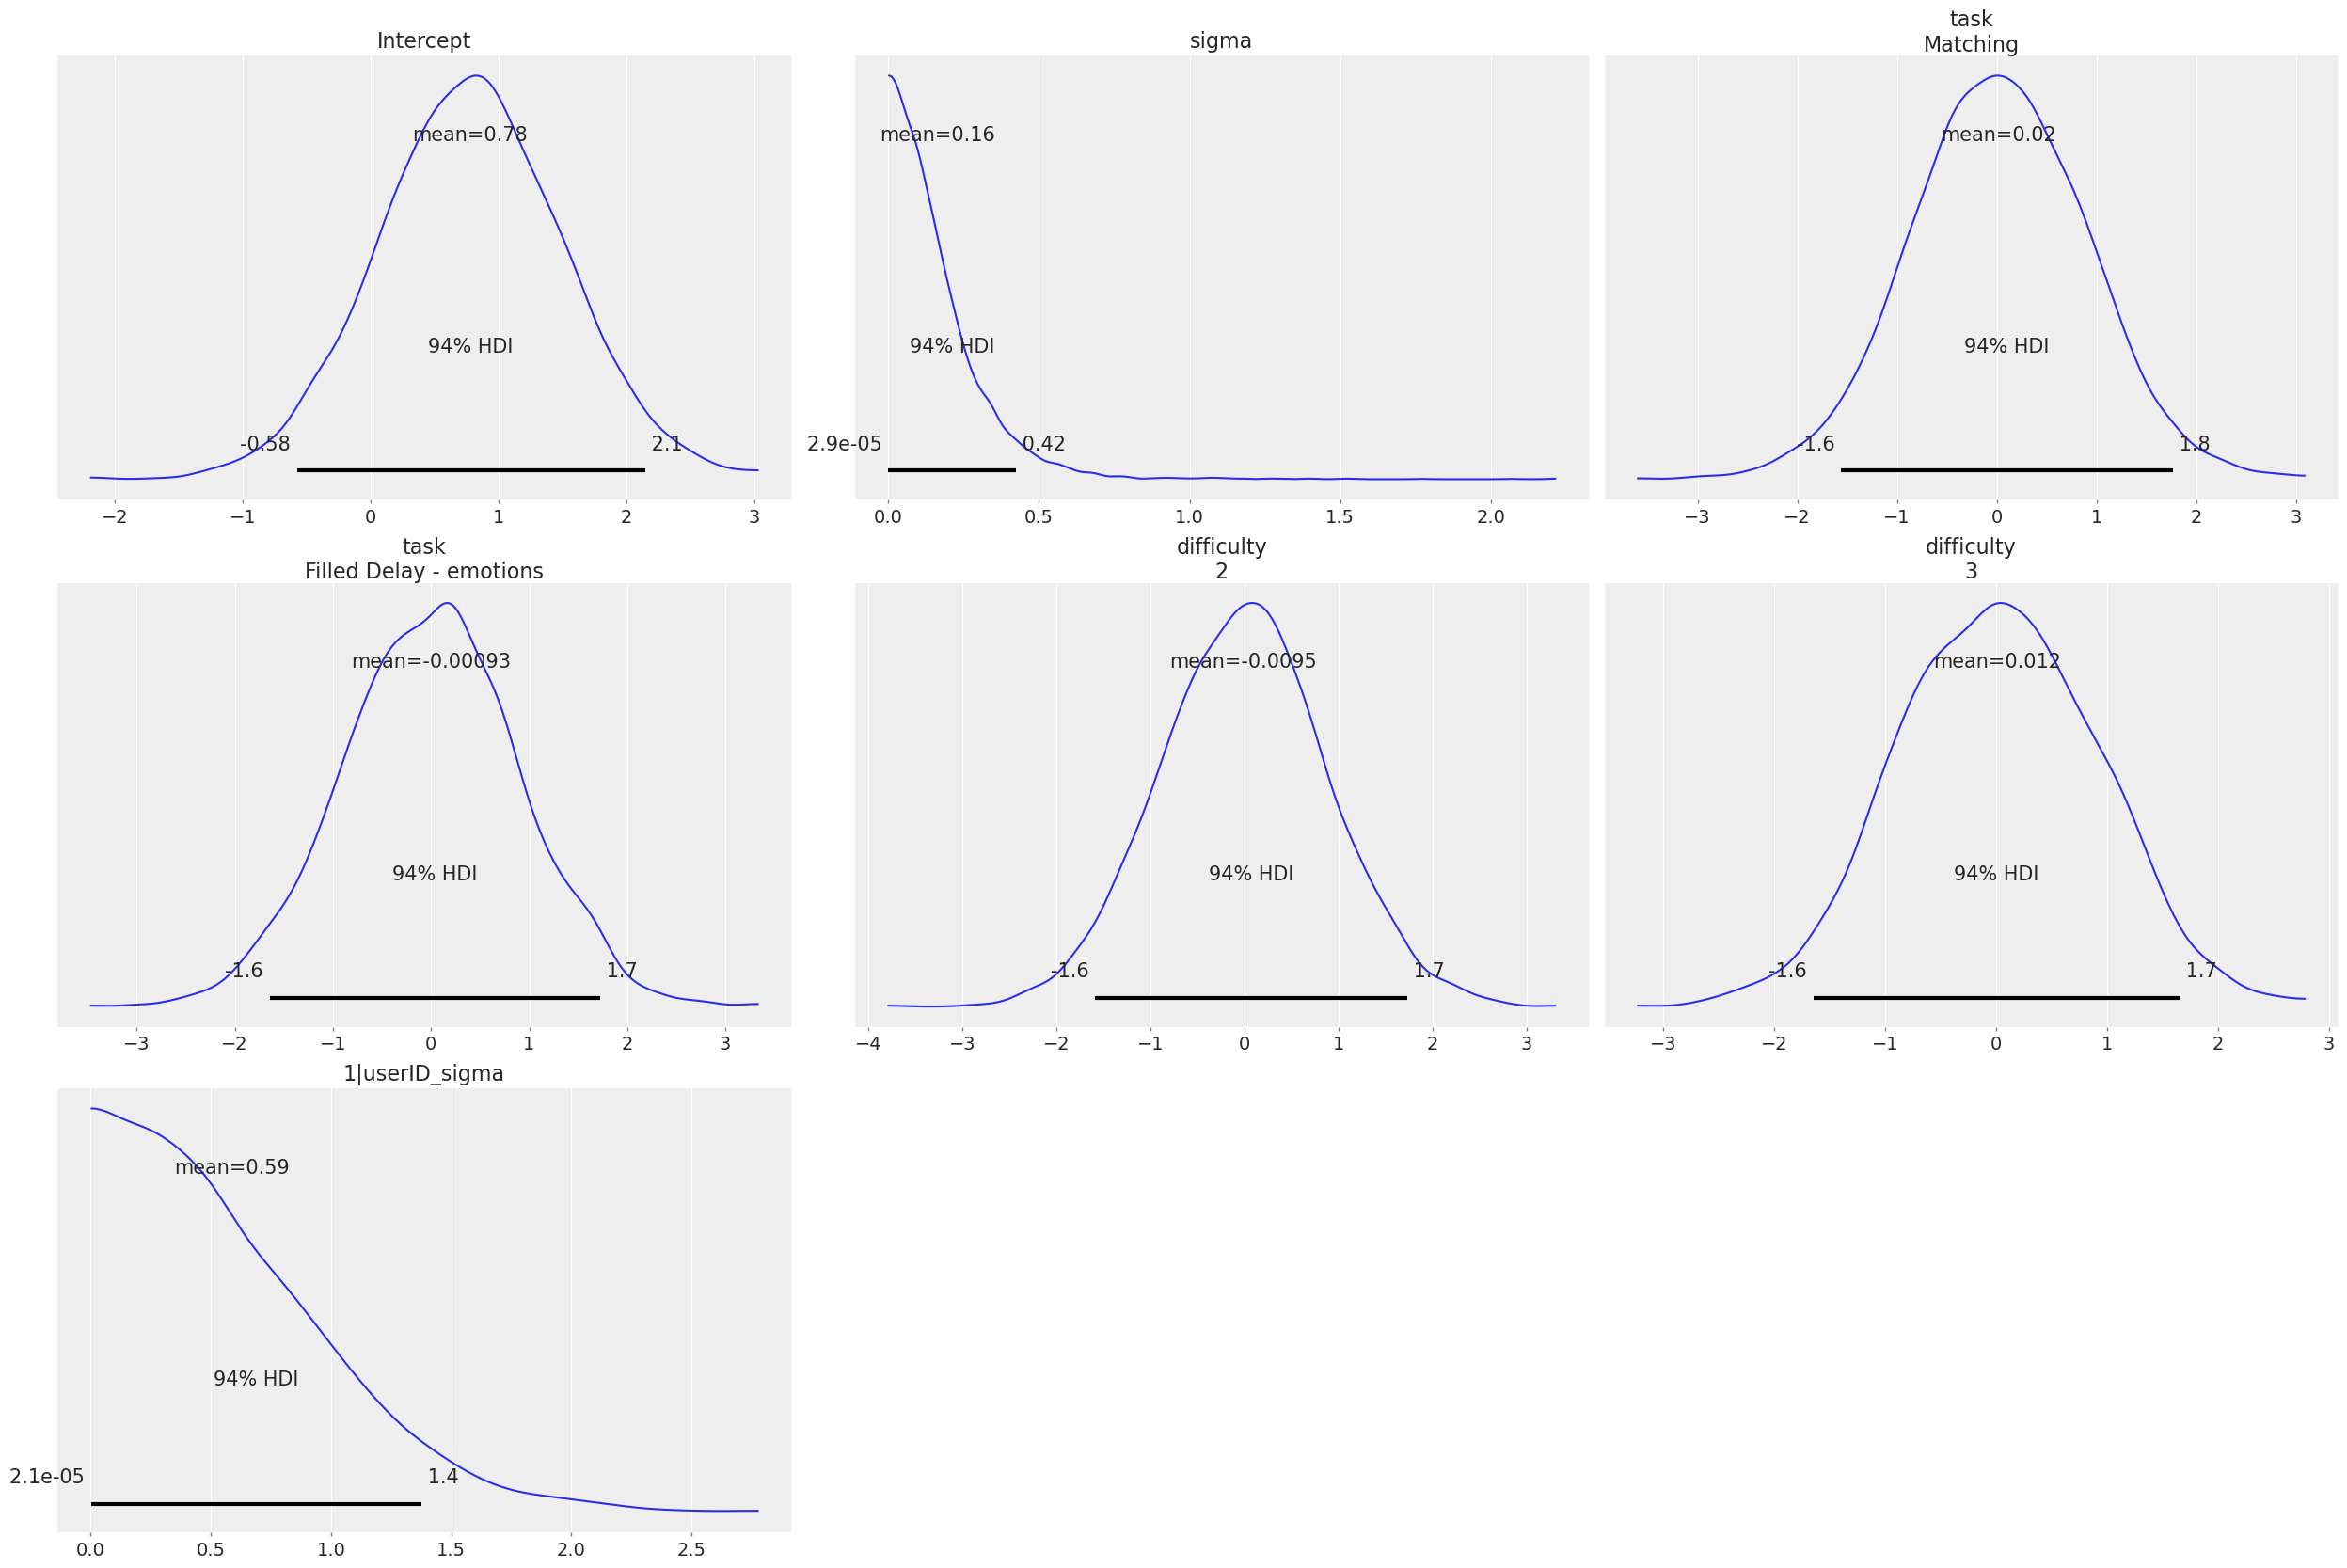

In [8]:
model_dic_bernoulli[f][formulas2run[1]].plot_priors()

### check posterior

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

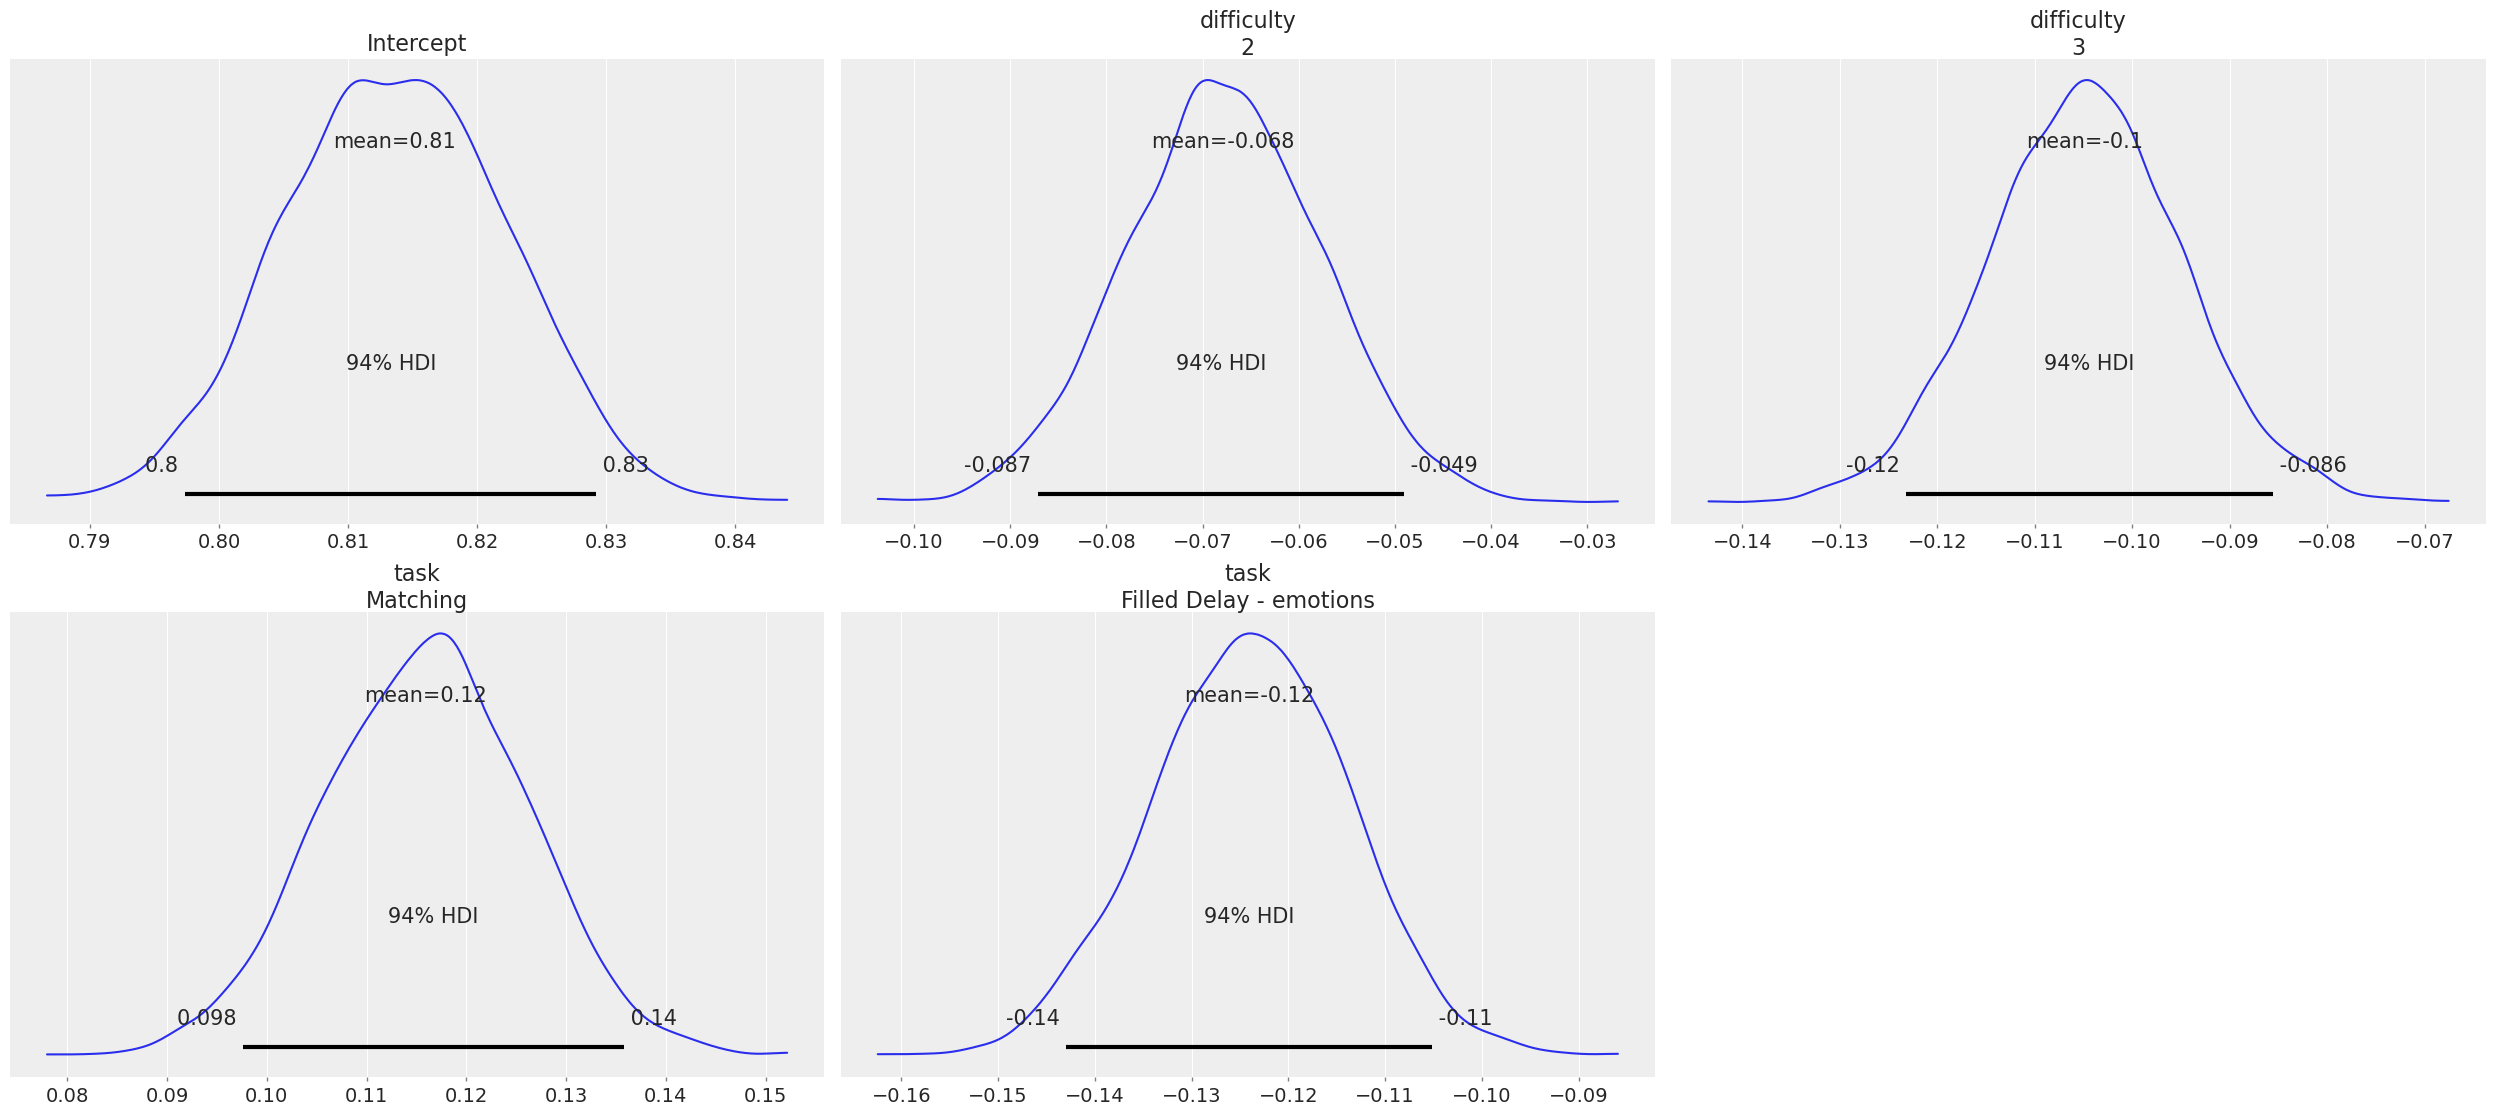

In [9]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[0]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: >]], dtype=object)

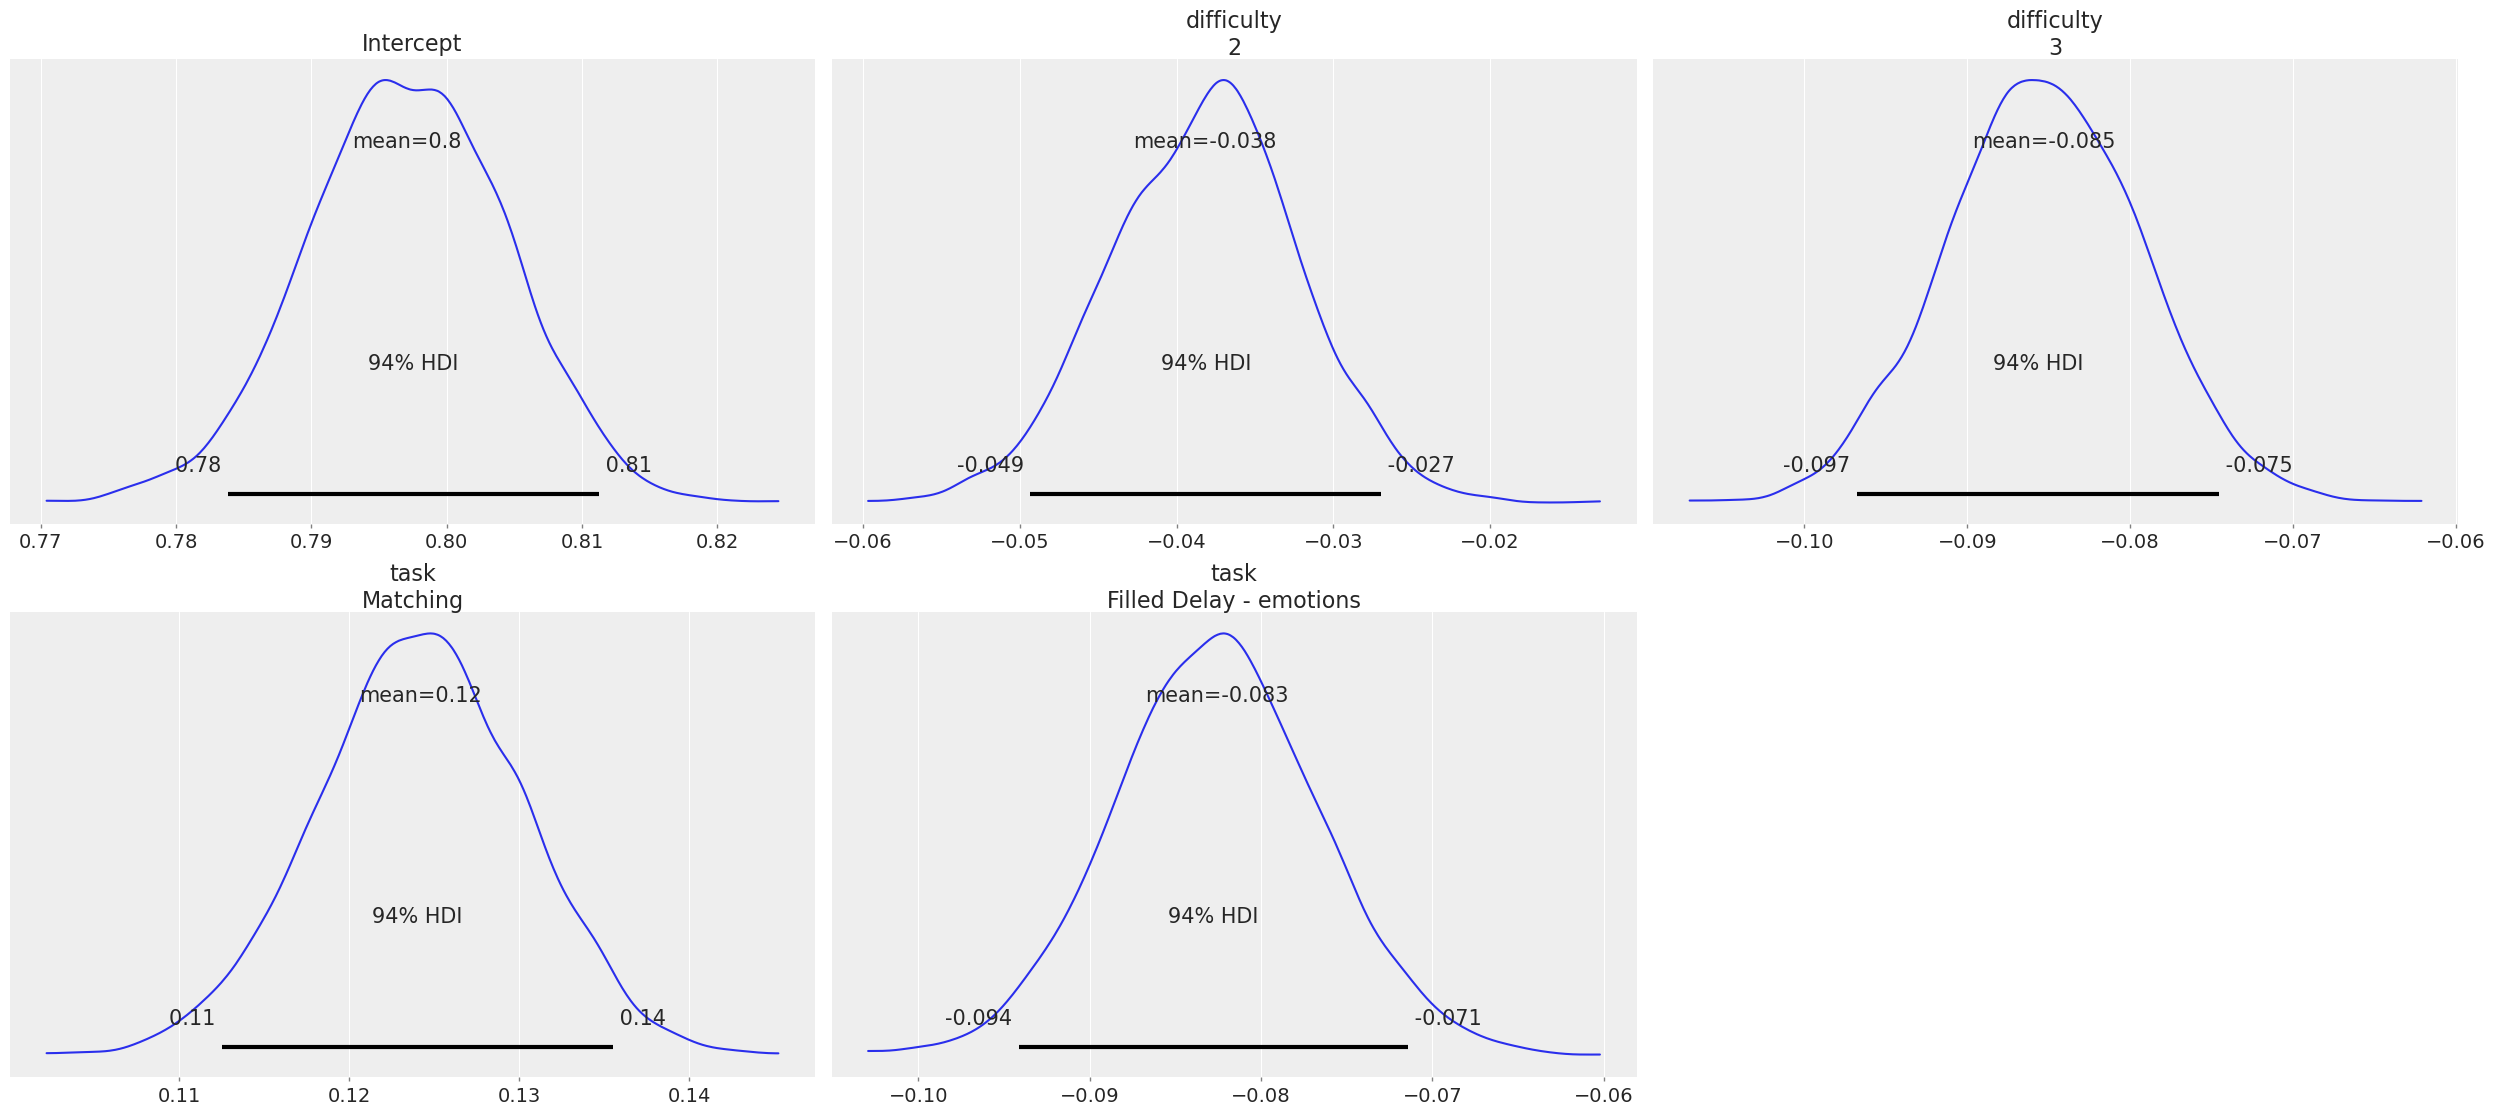

In [10]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[1]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

---
## Plot results

## Dataset 3 - morphed image as cue stimulus
[top](#top)

Dataset: dataset_3_other

Fitting formula correct_flt ~ task * difficulty + (1|userID)



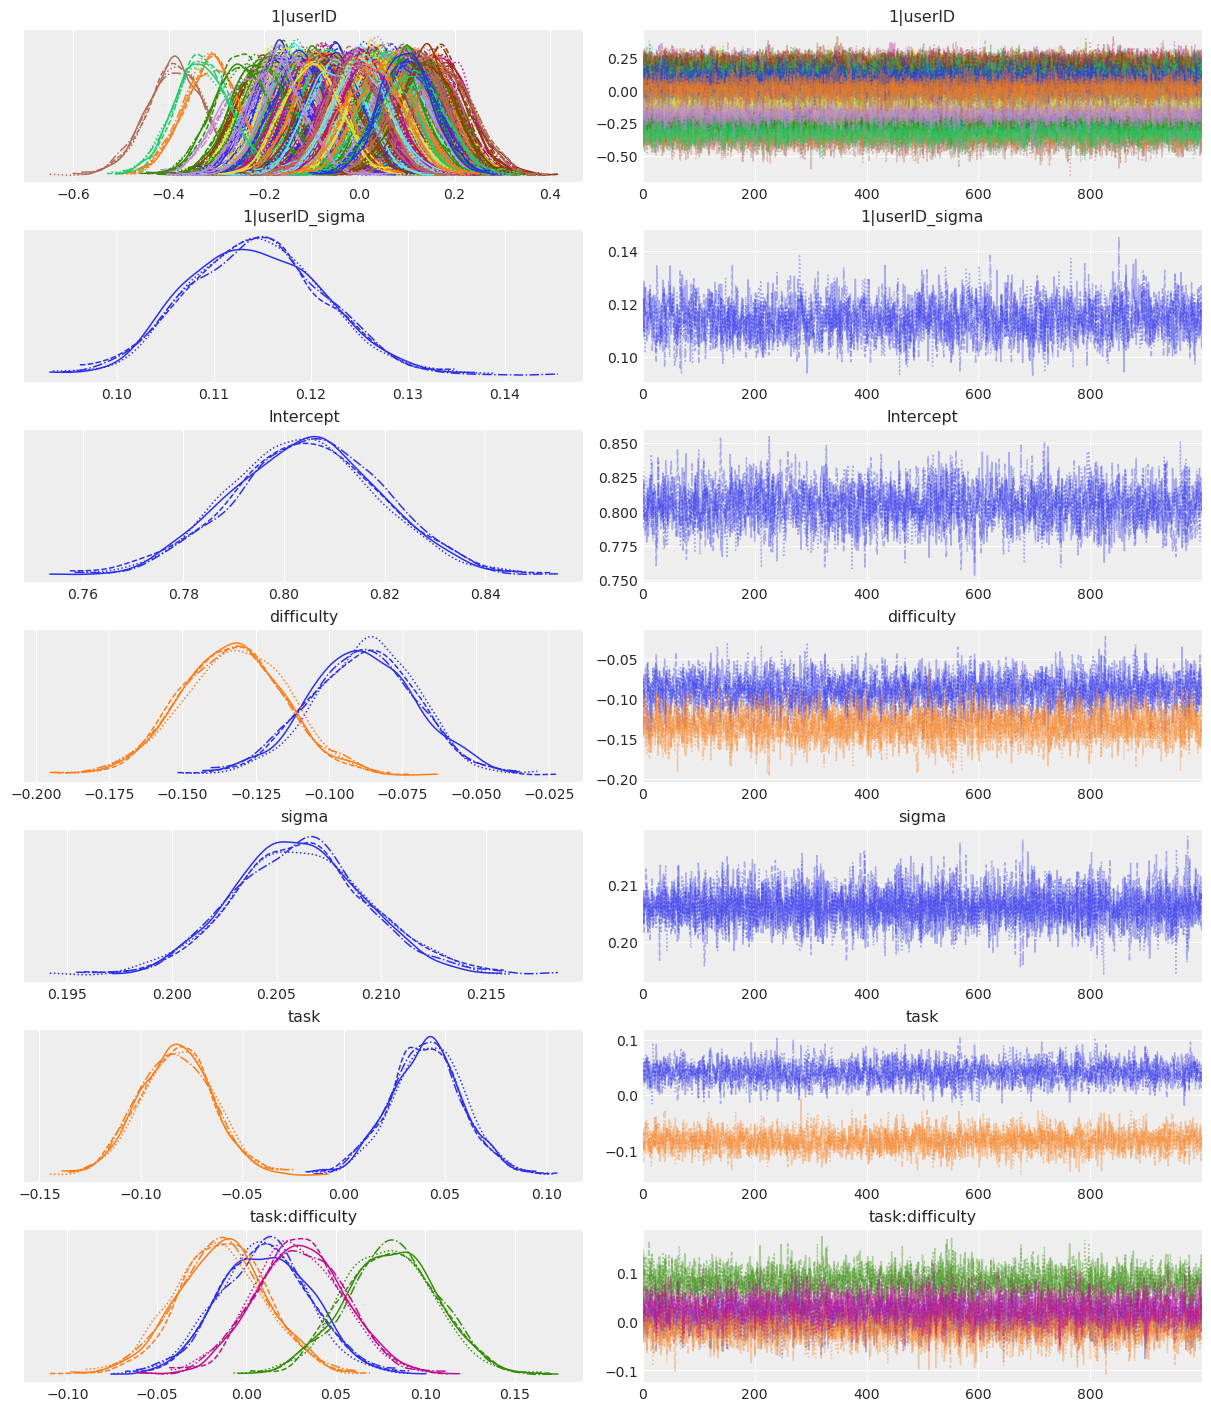

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.044  0.059  -0.074    0.150      0.001    0.001    9456.0   
1|userID[s_1002] -0.076  0.058  -0.181    0.034      0.001    0.001    8241.0   
1|userID[s_1006]  0.052  0.060  -0.062    0.163      0.001    0.001    8429.0   
1|userID[s_1012] -0.113  0.059  -0.223    0.001      0.001    0.001    7796.0   
1|userID[s_1015]  0.013  0.059  -0.100    0.119      0.001    0.001    8177.0   
1|userID[s_1016]  0.025  0.056  -0.078    0.129      0.001    0.001    8698.0   
1|userID[s_1017] -0.112  0.060  -0.221    0.006      0.001    0.001    8044.0   
1|userID[s_1036] -0.022  0.061  -0.136    0.092      0.001    0.001    9652.0   
1|userID[s_1042] -0.169  0.060  -0.287   -0.061      0.001    0.001    9271.0   
1|userID[s_1045]  0.117  0.061   0.008    0.234      0.001    0.001    7375.0   
1|userID[s_1046] -0.098  0.067  -0.220    0.034      0.001    0.001    7440.0   
1|userID[s_1047]  0.071  0.0

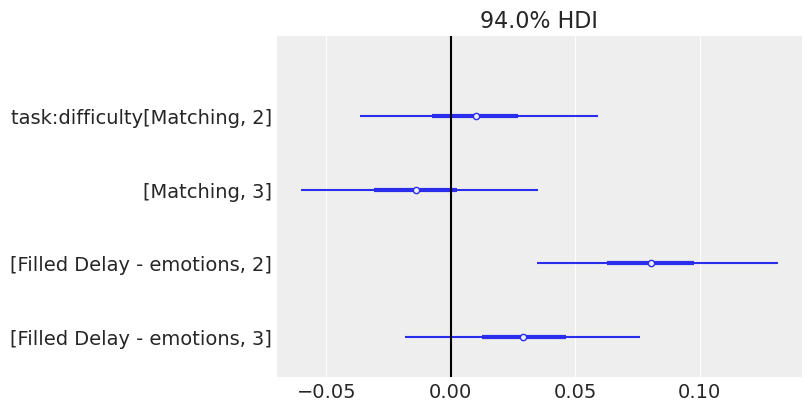

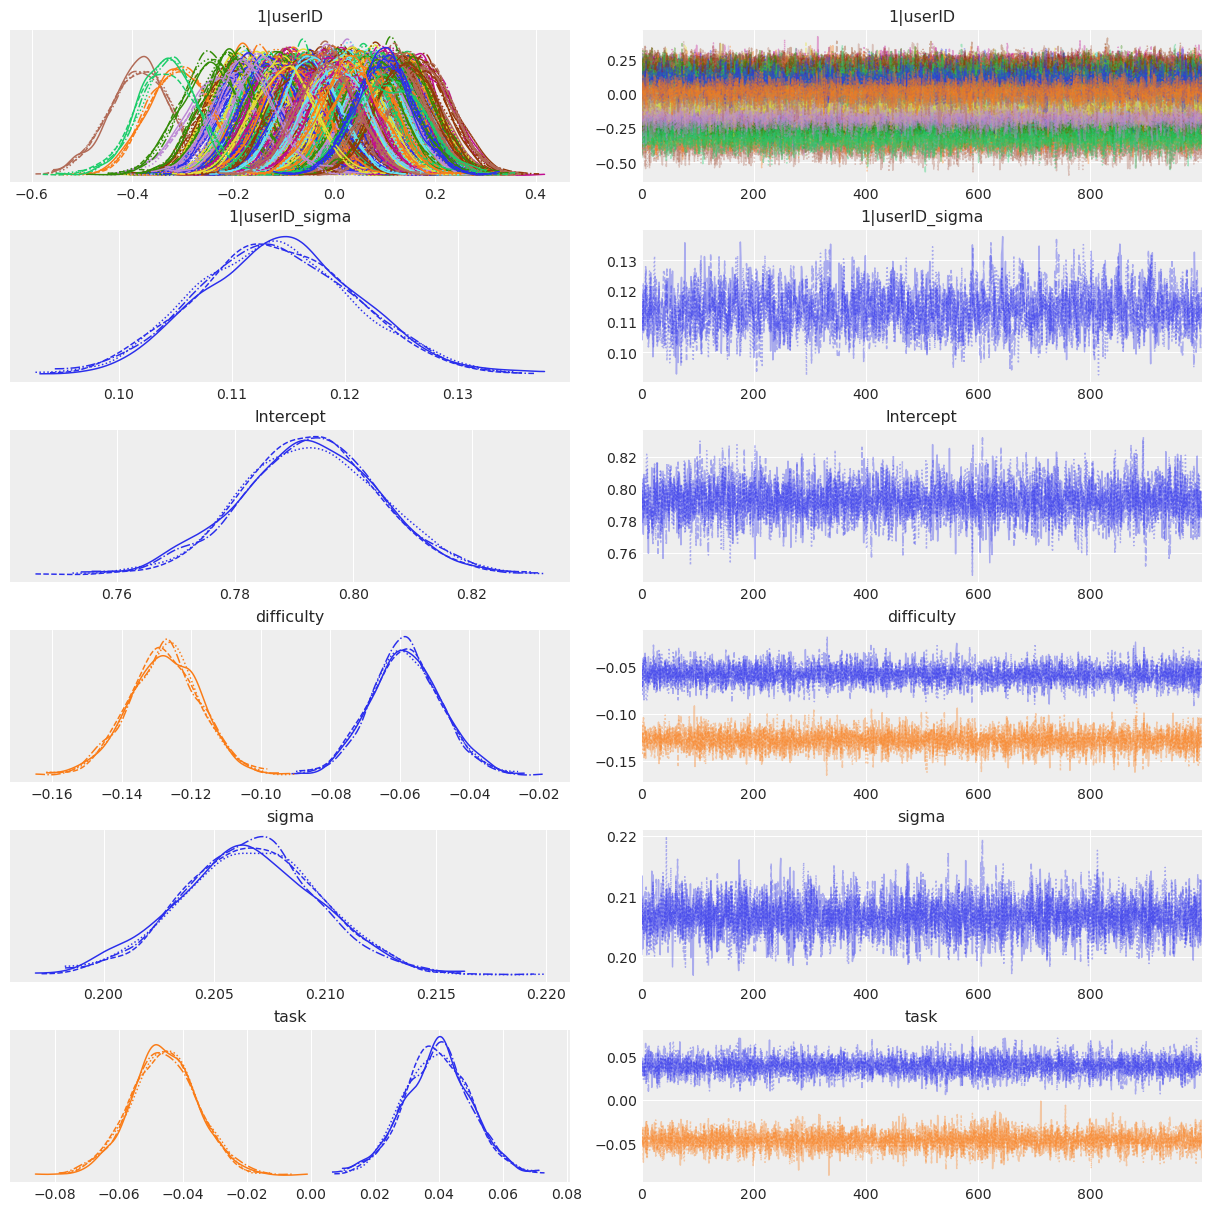

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.044  0.058  -0.065    0.150      0.001    0.001    7889.0   
1|userID[s_1002] -0.077  0.061  -0.183    0.040      0.001    0.001    9355.0   
1|userID[s_1006]  0.053  0.060  -0.064    0.161      0.001    0.001    7893.0   
1|userID[s_1012] -0.113  0.061  -0.230   -0.001      0.001    0.001    7754.0   
1|userID[s_1015]  0.012  0.059  -0.107    0.118      0.001    0.001    7789.0   
1|userID[s_1016]  0.025  0.058  -0.079    0.137      0.001    0.001    8468.0   
1|userID[s_1017] -0.112  0.059  -0.221   -0.003      0.001    0.001    7964.0   
1|userID[s_1036] -0.023  0.059  -0.131    0.090      0.001    0.001    8523.0   
1|userID[s_1042] -0.168  0.061  -0.286   -0.056      0.001    0.001    7849.0   
1|userID[s_1045]  0.118  0.058   0.005    0.225      0.001    0.001    7987.0   
1|userID[s_1046] -0.098  0.068  -0.228    0.022      0.001    0.001    7538.0   
1|userID[s_1047]  0.070  0.0

In [11]:
f = 'dataset_3_other'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

## Dataset - unmorphed image as cue stimulus
[top](#top)

Dataset: dataset_3_target_0

Fitting formula correct_flt ~ task * difficulty + (1|userID)



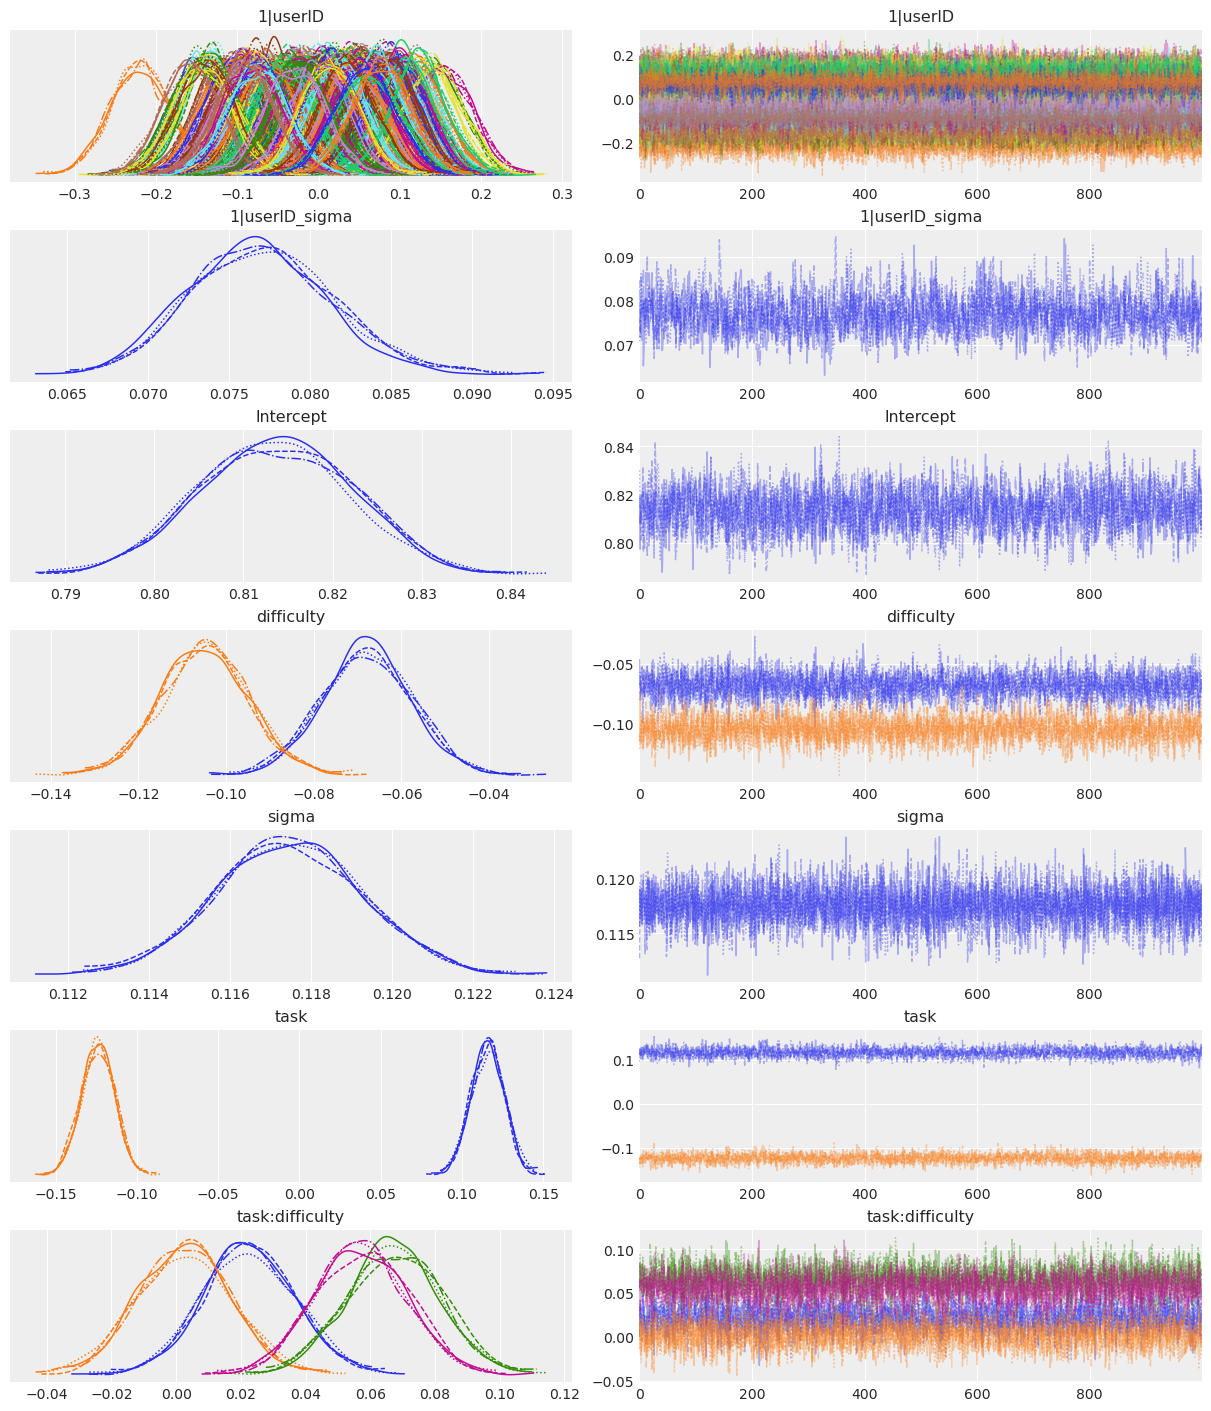

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.005  0.035  -0.062    0.070        0.0    0.001    7852.0   
1|userID[s_1002] -0.093  0.035  -0.162   -0.033        0.0    0.000    8270.0   
1|userID[s_1006]  0.019  0.032  -0.044    0.078        0.0    0.000    7851.0   
1|userID[s_1012]  0.014  0.035  -0.052    0.078        0.0    0.001    8703.0   
1|userID[s_1015] -0.026  0.035  -0.088    0.040        0.0    0.001    7975.0   
1|userID[s_1016]  0.019  0.035  -0.043    0.086        0.0    0.001    8602.0   
1|userID[s_1017] -0.024  0.035  -0.088    0.041        0.0    0.000    9424.0   
1|userID[s_1036]  0.036  0.036  -0.029    0.111        0.0    0.000    7837.0   
1|userID[s_1042]  0.083  0.035   0.016    0.146        0.0    0.000    7448.0   
1|userID[s_1045]  0.022  0.035  -0.041    0.091        0.0    0.001    6957.0   
1|userID[s_1046]  0.037  0.042  -0.041    0.114        0.0    0.001    7789.0   
1|userID[s_1047] -0.007  0.0

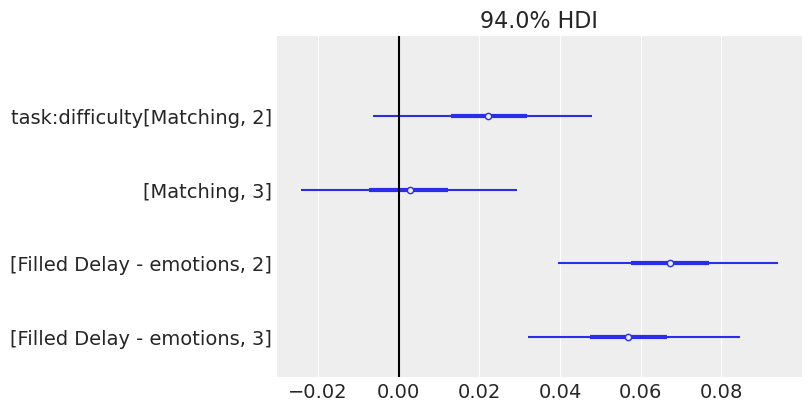

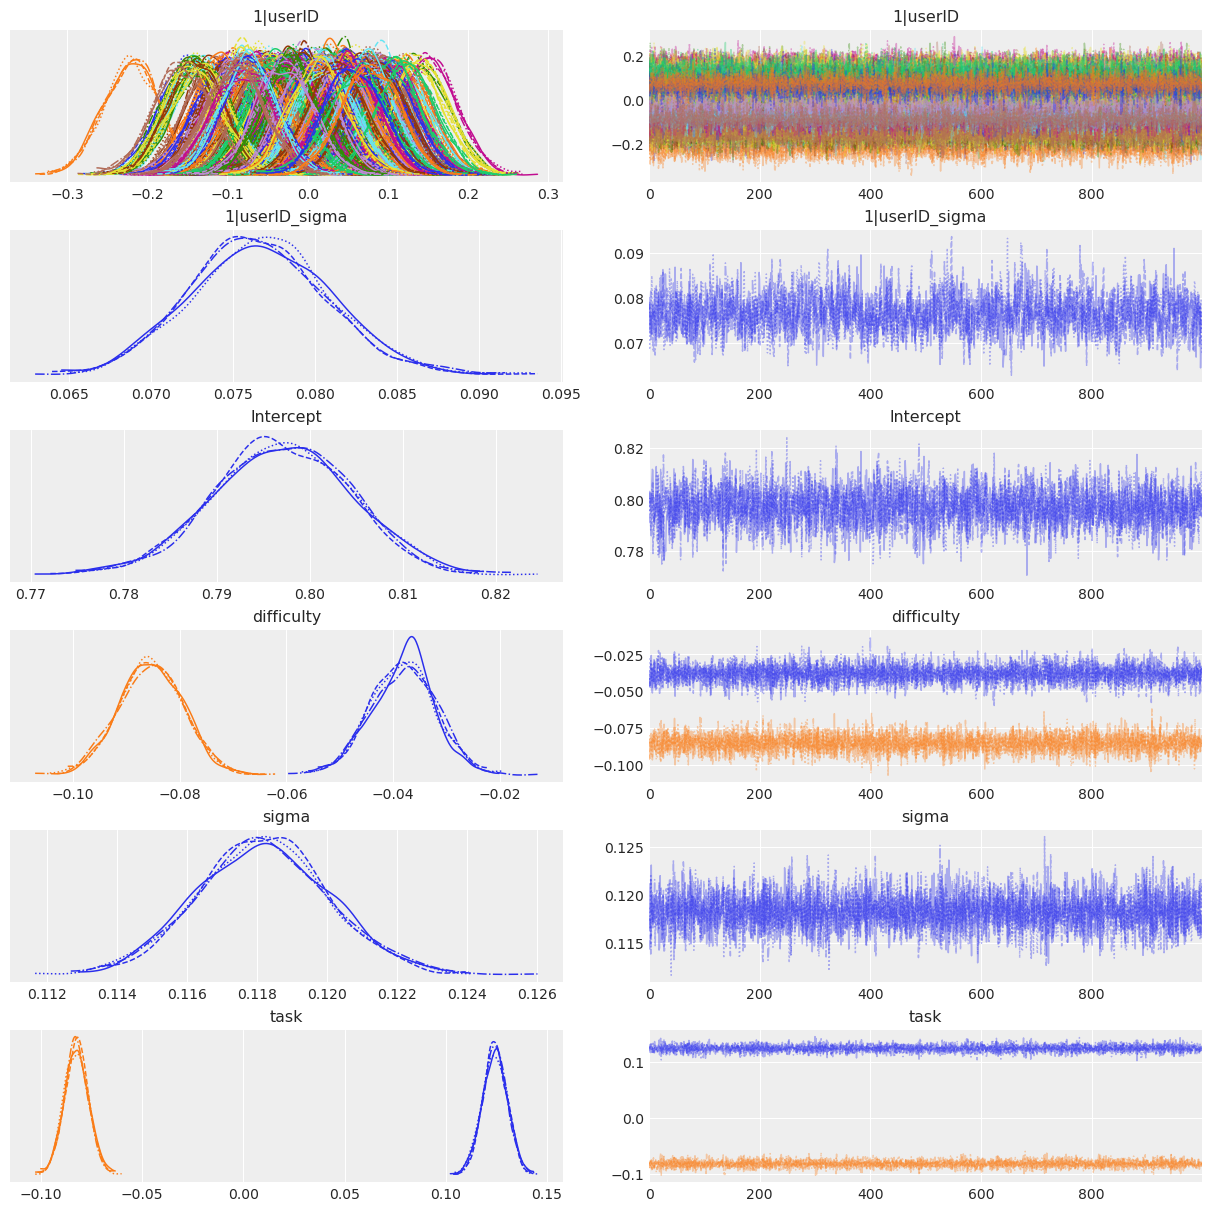

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1001]  0.004  0.035  -0.064    0.068        0.0    0.001    8048.0   
1|userID[s_1002] -0.093  0.035  -0.160   -0.029        0.0    0.000    8684.0   
1|userID[s_1006]  0.019  0.035  -0.048    0.082        0.0    0.001    7081.0   
1|userID[s_1012]  0.014  0.036  -0.053    0.081        0.0    0.001    7610.0   
1|userID[s_1015] -0.026  0.035  -0.093    0.039        0.0    0.000    8124.0   
1|userID[s_1016]  0.019  0.036  -0.050    0.085        0.0    0.001    6673.0   
1|userID[s_1017] -0.024  0.035  -0.087    0.046        0.0    0.001    7540.0   
1|userID[s_1036]  0.036  0.037  -0.032    0.103        0.0    0.000    7252.0   
1|userID[s_1042]  0.083  0.035   0.018    0.149        0.0    0.000    7283.0   
1|userID[s_1045]  0.023  0.037  -0.042    0.095        0.0    0.001    7314.0   
1|userID[s_1046]  0.037  0.040  -0.040    0.112        0.0    0.000    8061.0   
1|userID[s_1047] -0.007  0.0

In [12]:
f = 'dataset_3_target_0'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

### Compare all data
[top](#top)

dataset_3_other 

                                              rank    elpd_loo       p_loo  \
correct_flt ~ task * difficulty + (1|userID)     0  269.700257  195.086294   
correct_flt ~ task + difficulty + (1|userID)     1  267.185368  190.783338   

                                              elpd_diff   weight         se  \
correct_flt ~ task * difficulty + (1|userID)   0.000000  0.67001  36.280176   
correct_flt ~ task + difficulty + (1|userID)   2.514889  0.32999  36.113914   

                                                 dse  warning scale  
correct_flt ~ task * difficulty + (1|userID)  0.0000    False   log  
correct_flt ~ task + difficulty + (1|userID)  3.8728    False   log  

dataset_3_target_0 

                                              rank     elpd_loo       p_loo  \
correct_flt ~ task * difficulty + (1|userID)     0  1580.571772  207.951379   
correct_flt ~ task + difficulty + (1|userID)     1  1567.696461  205.023743   

                                       

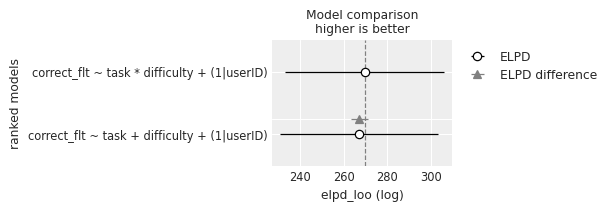

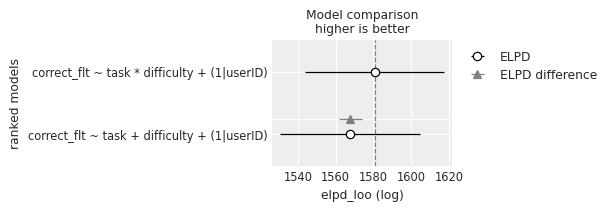

In [13]:
df_compare_formulas_bernoulli = {}
for f in result_dic_bernoulli.keys():
    print(f, '\n')
    df_compare_formulas_bernoulli[f] = az.compare(result_dic_bernoulli[f])
    
    print(df_compare_formulas_bernoulli[f])
    
    az.plot_compare(df_compare_formulas_bernoulli[f], insample_dev=False);

    
    print()
# df_compare_formulas_bernoulli[f]

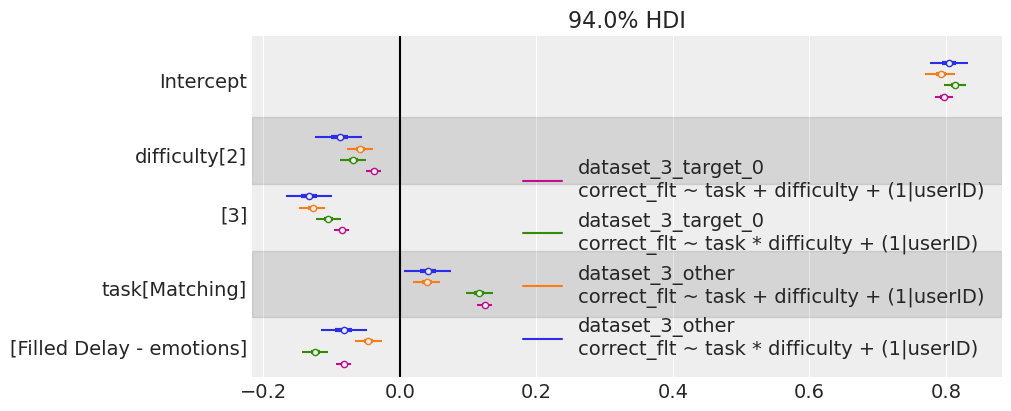

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
az.plot_forest(
    list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values()),
    model_names=[f'{f}\n{formula}' for f in result_dic_bernoulli.keys() for formula in formulas2run],
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1., 0), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()



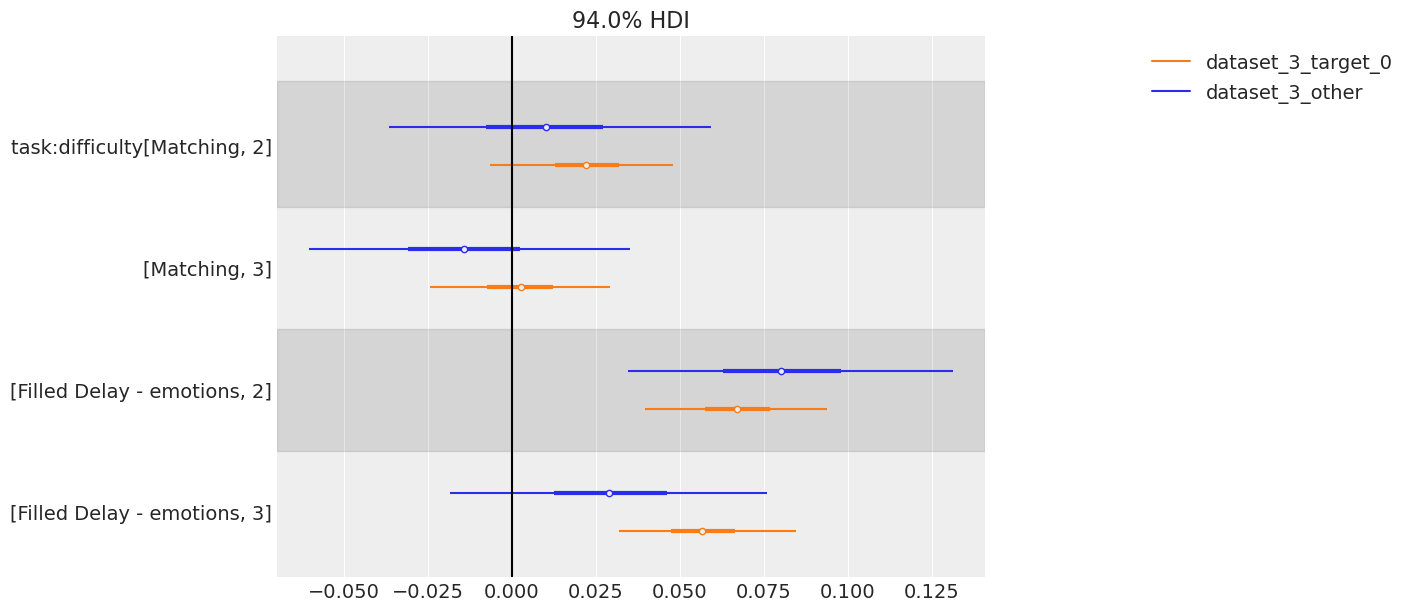

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))
az.plot_forest(
    (list(result_dic_bernoulli['dataset_3_other'].values())+\
    list(result_dic_bernoulli['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in result_dic_bernoulli.keys()],
    var_names=["task:difficulty"],
    combined=True,
#     figsize=(12, 10)
    ax=ax
);

ax.axvline(0, c='k')

# plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
# plt.show()


# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.6, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

### Run some predictions
[top](#top)

In [16]:
# hue_order = ["face matching", "delay", "interference"]
# interactions = ['face matching, 2', 'face matching, 3', 'interference, 2', 'interference, 3']
interactions = ['Matching, 2', 'Matching, 3', 'Filled Delay - emotions, 2', 'Filled Delay - emotions, 3']
fm2, fm3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]



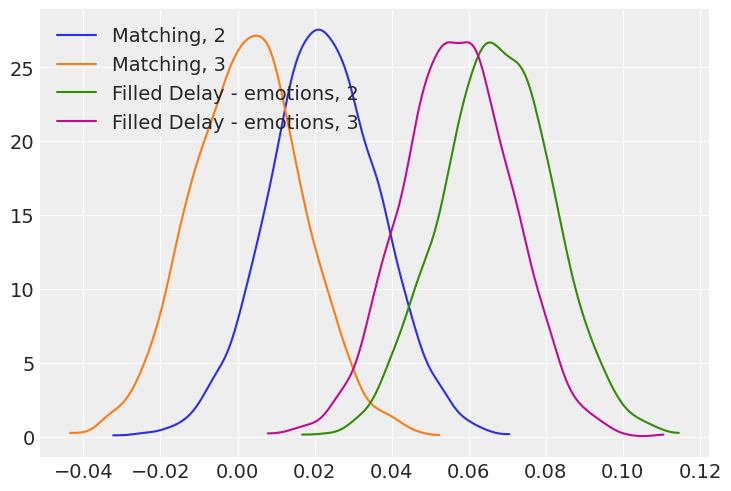

In [17]:
_, ax = plt.subplots()
for idx, x in enumerate([fm2, fm3, i2, i3]):
    az.plot_dist(x, label=x["task:difficulty_dim"].item(), plot_kwargs={"color": f"C{idx}"}, ax=ax)
ax.legend(loc="upper left");

In [18]:
# Probability that the M slope is less than 0

print(f"""
Probability that the M slope is less than 0:
level 2: {(fm2 < 0).mean().item()}
level 3: {(fm3 < 0).mean().item()}
""")


Probability that the M slope is less than 0:
level 2: 0.0575
level 3: 0.4255



---

In [19]:
for f in result_dic_bernoulli.keys():

    fm2, fm3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]
    print(f"""
Experiment {f}:
  Probability that the M slope is less than 0:
    level 2: {(fm2 < 0).mean().item()}
    level 3: {(fm3 < 0).mean().item()}
    
  Probability that the FD-e slope is less than 0:
    level 2: {(i2 < 0).mean().item()}
    level 3: {(i3 < 0).mean().item()}
    
    """)


Experiment dataset_3_other:
  Probability that the M slope is less than 0:
    level 2: 0.348
    level 3: 0.7155
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.00075
    level 3: 0.122
    
    

Experiment dataset_3_target_0:
  Probability that the M slope is less than 0:
    level 2: 0.0575
    level 3: 0.4255
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.0
    level 3: 0.0
    
    


### Save the inference
[top](#top)

It could be possible to use this:
```
result_dic_bernoulli['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)'].to_netcdf()
```

and the other datasets that were fitted, but it doesn't preserve the dictionary, so I use pickle.

In [20]:
# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic_bernoulli, f)

In [21]:
# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [22]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Fri May 16 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]
pandas    : 2.2.2
bambi     : 0.14.0
numpy     : 1.26.4
matplotlib: 3.9.2
arviz     : 0.19.0

Watermark: 2.4.3



[top](#top)